# JaxFEM – Statische Träger-Berechnungen

Dieses Notebook dient als **Skill-Template** für statische Berechnungen mit JaxFEM (2-D Scheibe, lineare Elastizität).  
Enthält alle Features aus `2D_Scheibe.ipynb`:  
Verschiebungen · Spannungen (σ_xx, σ_yy, τ_xy, von-Mises) · Dehnungen · Hauptspannungstrajektorien · Querschnittsplot · **Schnittgrößen M / V / N**.

---

## Systeme

| Kürzel | Beschreibung |
|--------|--------------|
| **EFK** | Einfeldträger mit Kragarm |
| **ZF**  | Zweifeldträger |
| **DSL** | Einfeldträger mit Dreieck-Streckenlast (q₀ bei B, 0 bei A) |

---

### Konfiguration — hier anpassen

Setze `SYSTEM` auf `"EFK"`, `"ZF"` oder `"DSL"`.  
Alle weiteren Zellen laufen automatisch durch.

In [70]:
import jax
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.interpolate import LinearNDInterpolator

from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh

print("JAX-Version:", jax.__version__)

# ════════════════════════════════════════════════════════════
#  SYSTEM-AUSWAHL
# ════════════════════════════════════════════════════════════
SYSTEM = "DSL"   # "EFK" | "ZF" | "DSL"

# ────────────────────────────────────────────────────────────
#  Einfeldträger mit Kragarm (EFK)
#  A (Gelenk)               B (Gelenk)   Kragarm → C (frei)
#  |←────── L1 ────────────→|←── L2 ──→|
# ────────────────────────────────────────────────────────────
EFK = dict(
    L1   = 4.0,   # m – Stützweite
    L2   = 2.0,   # m – Kragarm
    h    = 0.4,   # m – Trägerhöhe
    q    = 10.0,  # kN/m² – gleichmäßige Streckenlast
    F    = 0.0,   # kN – Einzellast am Kragarmende
    Nx   = 120,
    Ny   = 20,
)

# ────────────────────────────────────────────────────────────
#  Zweifeldträger (ZF)
#  A (Gelenk)    B (Mittelauflager)    C (Gelenk)
#  |←── L1 ──→|←────── L2 ──────→|
# ────────────────────────────────────────────────────────────
ZF = dict(
    L1   = 2.0,   # m – Stützweite Feld 1
    L2   = 4.0,   # m – Stützweite Feld 2
    h    = 0.4,   # m – Trägerhöhe
    q    = 10.0,  # kN/m² – gleichmäßige Streckenlast
    Nx   = 120,
    Ny   = 20,
)

# ────────────────────────────────────────────────────────────
#  Einfeldträger mit Dreieck-Streckenlast (DSL)
#  q(x) = q0 * x/L  → 0 bei A, q0 bei B
#  Resultante FR = q0*L/2, Angriffspunkt bei x = 2L/3
#  RA = q0*L/6   RB = q0*L/3
# ────────────────────────────────────────────────────────────
DSL = dict(
    L    = 6.0,   # m – Stützweite
    h    = 0.4,   # m – Trägerhöhe
    q0   = 10.0,  # kN/m² – Maximalwert der Dreiecks-Last (bei B)
    Nx   = 120,
    Ny   = 20,
)

# ────────────────────────────────────────────────────────────
#  Materialparameter (Stahl, Einheiten kN + m)
# ────────────────────────────────────────────────────────────
E  = 210_000.0   # kN/m²
nu = 0.3
mu    = E / (2.0 * (1.0 + nu))
lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

print(f"System: {SYSTEM}")

JAX-Version: 0.6.2
System: DSL


## 1. System aufstellen

JaxFEM modelliert den Träger als **2-D Scheibe** (Ebener Spannungszustand, Einheitstiefe b = 1 m).  
Die Geometrie ist ein Rechteck `[0, Lx] × [0, h]`.  
Auflager und Lasten werden über Randbedingungen definiert.

In [71]:
if SYSTEM == "EFK":
    cfg = EFK
    Lx = cfg["L1"] + cfg["L2"]
    h  = cfg["h"]
    q  = cfg["q"]
    F_krag = cfg["F"]
    xA = 0.0
    xB = cfg["L1"]
    print(f"EFK: L1={cfg['L1']} m  L2={cfg['L2']} m  h={h} m")
    print(f"     q={q} kN/m²  F={F_krag} kN  Lx={Lx} m")

elif SYSTEM == "ZF":
    cfg = ZF
    Lx = cfg["L1"] + cfg["L2"]
    h  = cfg["h"]
    q  = cfg["q"]
    F_krag = 0.0
    xA = 0.0
    xB = cfg["L1"]
    xC = Lx
    print(f"ZF: L1={cfg['L1']} m  L2={cfg['L2']} m  h={h} m")
    print(f"    q={q} kN/m²  Lx={Lx} m")

elif SYSTEM == "DSL":
    cfg = DSL
    Lx = cfg["L"]
    h  = cfg["h"]
    q0 = cfg["q0"]
    F_krag = 0.0
    xA = 0.0
    xB = Lx
    print(f"DSL: L={Lx} m  h={h} m  q0={q0} kN/m²")
    print(f"     RA = {q0*Lx/6:.3f} kN   RB = {q0*Lx/3:.3f} kN")

else:
    raise ValueError(f"Unbekanntes System: {SYSTEM}")

DSL: L=6.0 m  h=0.4 m  q0=10.0 kN/m²
     RA = 10.000 kN   RB = 20.000 kN


## 2. Problem-Klasse & Netz

In [72]:
# Für EFK/ZF: gleichmäßige Streckenlast als Flächenlast auf Oberkante
# Für DSL: ortsabhängige Dreiecks-Last q(x) = q0 * x/L
# Konvention JaxFEM: surface_map positiver y-Wert → Kraft nach unten

if SYSTEM in ("EFK", "ZF"):
    t_q  = cfg["q"]
    t_F  = (F_krag / h) if (SYSTEM == "EFK" and h > 0) else 0.0

elif SYSTEM == "DSL":
    q0_val = cfg["q0"]
    L_val  = cfg["L"]


class LinearElasticity2D(Problem):
    """Lineare Elastizität, 2-D Scheibe (ebener Spannungszustand)."""

    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma = lmbda * np.trace(epsilon) * np.eye(self.dim) + 2.0 * mu * epsilon
            return sigma
        return stress

    def get_surface_maps(self):
        if SYSTEM == "DSL":
            # Dreiecks-Last: ortsabhängig auf der Oberkante
            def load_top_triangle(u, x):
                # x[0] = x-Koordinate des Integrationspunkts auf der Oberkante
                q_local = q0_val * x[0] / L_val
                return np.array([0.0, q_local])
            return [load_top_triangle]

        elif SYSTEM == "EFK" and abs(t_F) > 0:
            def load_top(u, x):
                return np.array([0.0, t_q])
            def load_right(u, x):
                return np.array([0.0, t_F])
            return [load_top, load_right]

        else:
            def load_top(u, x):
                return np.array([0.0, t_q])
            return [load_top]

In [73]:
ele_type  = "QUAD4"
cell_type = get_meshio_cell_type(ele_type)

meshio_mesh = rectangle_mesh(Nx=cfg["Nx"], Ny=cfg["Ny"], domain_x=Lx, domain_y=h)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

print(f"Netz: {len(meshio_mesh.points)} Knoten, {len(meshio_mesh.cells_dict[cell_type])} Elemente")
print(f"Elementgröße ca. Δx={Lx/cfg['Nx']:.3f} m  Δy={h/cfg['Ny']:.4f} m")

Netz: 2541 Knoten, 2400 Elemente
Elementgröße ca. Δx=0.050 m  Δy=0.0200 m


## 3. Randbedingungen

### Dirichlet (Auflager)

Gelenk-Auflager: Nur **untere Kante** des Trägers (y = 0) an den Auflagerpositionen.

| System | Auflager A | Auflager B | Auflager C |
|--------|------------|------------|------------|
| EFK | x=0, u_y=0, u_x=0 | x=L1, u_y=0 | — (freies Ende) |
| ZF | x=0, u_y=0, u_x=0 | x=L1, u_y=0 | x=L1+L2, u_y=0 |

Auflager werden als **Knoten-Randbedingung** an einer schmalen Toleranzzone modelliert.  
Linkes Auflager A: u_x = u_y = 0 (Festlager).  
Rechte Auflager: nur u_y = 0 (Loslager in x).

### Neumann (Lasten)

- Oberkante: gleichmäßige Streckenlast q [kN/m²]
- Rechte Kante (nur EFK mit F>0): Einzellast als Flächenlast

In [74]:
points = meshio_mesh.points
tol = (Lx / cfg["Nx"]) * 0.6

def zero(point):
    return 0.0

def at_A_bottom(point):
    return np.isclose(point[0], xA, atol=tol) & np.isclose(point[1], 0.0, atol=tol)

def at_B_bottom(point):
    return np.isclose(point[0], xB, atol=tol) & np.isclose(point[1], 0.0, atol=tol)

def top(point):
    return np.isclose(point[1], h, atol=tol)

def right(point):
    return np.isclose(point[0], Lx, atol=tol)

if SYSTEM == "ZF":
    def at_C_bottom(point):
        return np.isclose(point[0], xC, atol=tol) & np.isclose(point[1], 0.0, atol=tol)

# ── Dirichlet ─────────────────────────────────────────────────────────────────
if SYSTEM == "EFK":
    dirichlet_bc_info = [
        [at_A_bottom, at_A_bottom, at_B_bottom],
        [0,           1,           1          ],
        [zero,        zero,        zero       ],
    ]
elif SYSTEM == "ZF":
    dirichlet_bc_info = [
        [at_A_bottom, at_A_bottom, at_B_bottom, at_C_bottom],
        [0,           1,           1,            1          ],
        [zero,        zero,        zero,         zero       ],
    ]
elif SYSTEM == "DSL":
    # Einfeldträger A–B: Festlager A (u_x=u_y=0), Loslager B (u_y=0)
    dirichlet_bc_info = [
        [at_A_bottom, at_A_bottom, at_B_bottom],
        [0,           1,           1          ],
        [zero,        zero,        zero       ],
    ]

# ── Neumann ───────────────────────────────────────────────────────────────────
if SYSTEM == "EFK" and abs(t_F) > 0:
    location_fns = [top, right]
else:
    location_fns = [top]

print("Randbedingungen definiert.")
print(f"  Dirichlet: {len(dirichlet_bc_info[0])}  |  Neumann: {len(location_fns)}")

Randbedingungen definiert.
  Dirichlet: 3  |  Neumann: 1


## 4. Lösen

In [75]:
problem = LinearElasticity2D(
    mesh=mesh,
    vec=2,
    dim=2,
    ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)
sol = solver(problem, solver_options={"umfpack_solver": {}})
print("Lösung berechnet. Shape:", sol[0].shape)

[04-20 03:27:08][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-20 03:27:08][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[04-20 03:27:08][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[04-20 03:27:08][DEBUG] jax_fem: Done pre-computations, took 0.019672870635986328 [s]
[04-20 03:27:08][INFO] jax_fem: Solving a problem with 2400 cells, 2541x2 = 5082 dofs.
[04-20 03:27:08][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[04-20 03:27:08][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-20 03:27:08][DEBUG] jax_fem: Start timing
[04-20 03:27:08][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-20 03:27:08][DEBUG] jax_fem: Function split_and_compute_cell took 0.0385 seconds
[04-20 03:27:08][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-20 03:27:08][DEBUG] jax_fem: Before, l_2 res = 8.75888306808071, relative l_2 

Lösung berechnet. Shape: (2541, 2)


## 5. Ergebnisse

### 5.1 Verschiebungen & Vergleich Balkenbiegeformel

FEM  w_max = -255.930 mm
Ana. w_max (DSL, Näherung): -75.335 mm
Überhöhungsfaktor: ×1


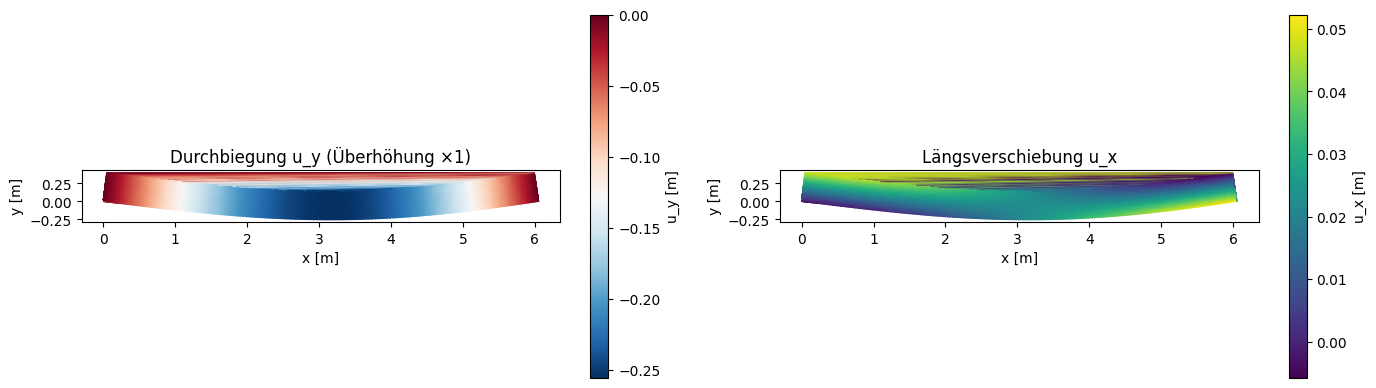

In [76]:
ux = sol[0][:, 0]
uy = sol[0][:, 1]

w_fem = float(np.min(uy))
print(f"FEM  w_max = {w_fem*1000:.3f} mm")

I = 1.0 * h**3 / 12.0   # m⁴

if SYSTEM == "EFK":
    L1, L2 = cfg["L1"], cfg["L2"]
    w_ana = -5.0 * cfg["q"] * L1**4 / (384.0 * E * I)
    print(f"Ana. w_max (Einfeldträger A–B, nur q): {w_ana*1000:.3f} mm  (Näherung)")

elif SYSTEM == "ZF":
    L_avg = (cfg["L1"] + cfg["L2"]) / 2
    w_ana = -0.005416 * cfg["q"] * L_avg**4 / (E * I)
    print(f"Ana. w_max (ZF, Näherung L_avg={L_avg:.1f} m): {w_ana*1000:.3f} mm")

elif SYSTEM == "DSL":
    L = cfg["L"]; q0 = cfg["q0"]
    # w_max bei x = 0.5193·L: w = q0·L⁴/(153.6·E·I)  (Tabellenformel)
    w_ana = -q0 * L**4 / (153.6 * E * I)
    print(f"Ana. w_max (DSL, Näherung): {w_ana*1000:.3f} mm")

# Überhöhung: maximal so wählen, dass verformte Geometrie ≤ 30 % der Trägerhöhe auslenkt
max_disp = abs(w_fem) if abs(w_fem) > 1e-10 else 1.0
scale_target = 0.3 * h          # Ziel-Auslenkung in y: 30 % von h
scale = min(scale_target / max_disp, 50.0)   # nie mehr als Faktor 50
scale = max(scale, 1.0)
scale = round(scale, 0)

x_def = points[:, 0] + scale * onp.array(ux)
y_def = points[:, 1] + scale * onp.array(uy)

print(f"Überhöhungsfaktor: ×{scale:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sc0 = axes[0].tripcolor(x_def, y_def, onp.array(uy), shading="gouraud", cmap="RdBu_r")
plt.colorbar(sc0, ax=axes[0], label="u_y [m]")
axes[0].set_title(f"Durchbiegung u_y (Überhöhung ×{scale:.0f})")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_aspect("equal")

sc1 = axes[1].tripcolor(x_def, y_def, onp.array(ux), shading="gouraud", cmap="viridis")
plt.colorbar(sc1, ax=axes[1], label="u_x [m]")
axes[1].set_title("Längsverschiebung u_x")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

### 5.2 Spannungen & Dehnungen (Gauss-Punkt-Extrapolation)

In [77]:
def compute_stress_strain_at_nodes(problem, sol_array):
    """
    Berechnet Spannungs- und Dehnungstensoren an jedem Knoten via
    Gauss-Punkt-Berechnung + Nearest-Neighbor-Extrapolation.
    Gibt zurück: sigma (N,3) = [sxx, syy, sxy], eps (N,3) = [exx, eyy, exy]
    """
    cells = meshio_mesh.cells_dict[get_meshio_cell_type(ele_type)]

    all_gp_coords = []
    all_sigma     = []
    all_eps       = []

    gauss_pts = onp.array([-1/onp.sqrt(3), 1/onp.sqrt(3)])
    gp_pairs  = [(xi, eta) for xi in gauss_pts for eta in gauss_pts]

    for cell in cells:
        x_cell = points[cell]
        u_cell = onp.array(sol_array[cell])

        for (xi, eta) in gp_pairs:
            N = onp.array([
                0.25*(1-xi)*(1-eta),
                0.25*(1+xi)*(1-eta),
                0.25*(1+xi)*(1+eta),
                0.25*(1-xi)*(1+eta),
            ])
            dN_dxi = onp.array([
                [-(1-eta), -(1-xi)],
                [ (1-eta), -(1+xi)],
                [ (1+eta),  (1+xi)],
                [-(1+eta),  (1-xi)],
            ]) * 0.25

            J    = dN_dxi.T @ x_cell
            Jinv = onp.linalg.inv(J)
            dN_dx = dN_dxi @ Jinv.T
            x_gp  = N @ x_cell
            grad_u = dN_dx.T @ u_cell

            eps_tensor = 0.5 * (grad_u + grad_u.T)
            exx = eps_tensor[0, 0]
            eyy = eps_tensor[1, 1]
            exy = eps_tensor[0, 1]

            sxx = (lmbda + 2*mu) * exx + lmbda * eyy
            syy = lmbda * exx + (lmbda + 2*mu) * eyy
            sxy = 2 * mu * exy

            all_gp_coords.append(x_gp)
            all_sigma.append([sxx, syy, sxy])
            all_eps.append([exx, eyy, exy])

    all_gp_coords = onp.array(all_gp_coords)
    all_sigma     = onp.array(all_sigma)
    all_eps       = onp.array(all_eps)

    tree = cKDTree(all_gp_coords)
    _, idx = tree.query(points[:, :2])

    return all_sigma[idx], all_eps[idx]

sigma_nodes, eps_nodes = compute_stress_strain_at_nodes(problem, onp.array(sol[0]))

sxx = sigma_nodes[:, 0]
syy = sigma_nodes[:, 1]
sxy = sigma_nodes[:, 2]
exx = eps_nodes[:, 0]
eyy = eps_nodes[:, 1]
exy = eps_nodes[:, 2]

s_vm = onp.sqrt(sxx**2 - sxx*syy + syy**2 + 3*sxy**2)

print(f"σ_xx: min={sxx.min():.2f}  max={sxx.max():.2f}  kN/m²")
print(f"σ_yy: min={syy.min():.2f}  max={syy.max():.2f}  kN/m²")
print(f"τ_xy: min={sxy.min():.2f}  max={sxy.max():.2f}  kN/m²")
print(f"von Mises σ_v: max={s_vm.max():.2f}  kN/m²")

σ_xx: min=-7348.22  max=3168.22  kN/m²
σ_yy: min=-3132.89  max=1059.93  kN/m²
τ_xy: min=-6737.70  max=1529.55  kN/m²
von Mises σ_v: max=13303.39  kN/m²


### 5.3 Spannungs-Plots

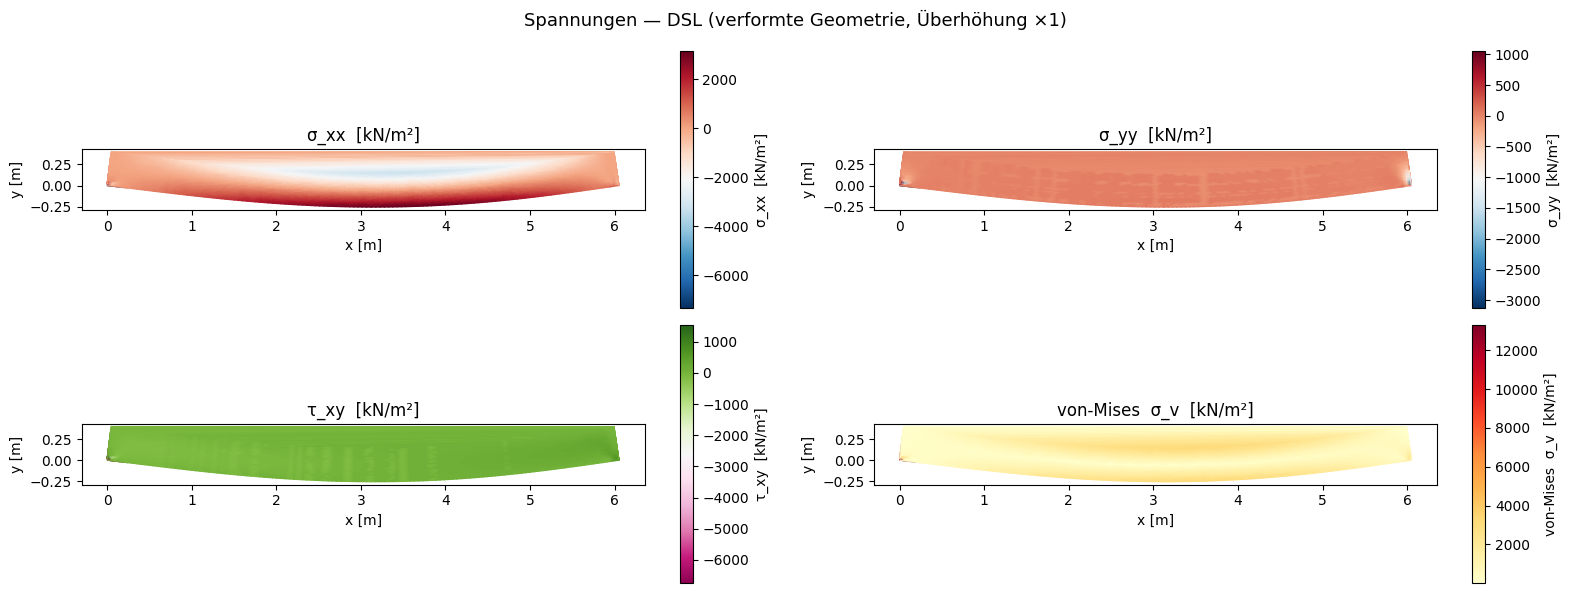

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6))
axes = axes.flatten()

plots = [
    (sxx, "σ_xx  [kN/m²]", "RdBu_r"),
    (syy, "σ_yy  [kN/m²]", "RdBu_r"),
    (sxy, "τ_xy  [kN/m²]", "PiYG"),
    (s_vm, "von-Mises  σ_v  [kN/m²]", "YlOrRd"),
]

for ax, (data, label, cmap) in zip(axes, plots):
    sc = ax.tripcolor(x_def, y_def, onp.array(data), shading="gouraud", cmap=cmap)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(label)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

plt.suptitle(f"Spannungen — {SYSTEM} (verformte Geometrie, Überhöhung ×{scale:.0f})", fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 Dehnungs-Plots

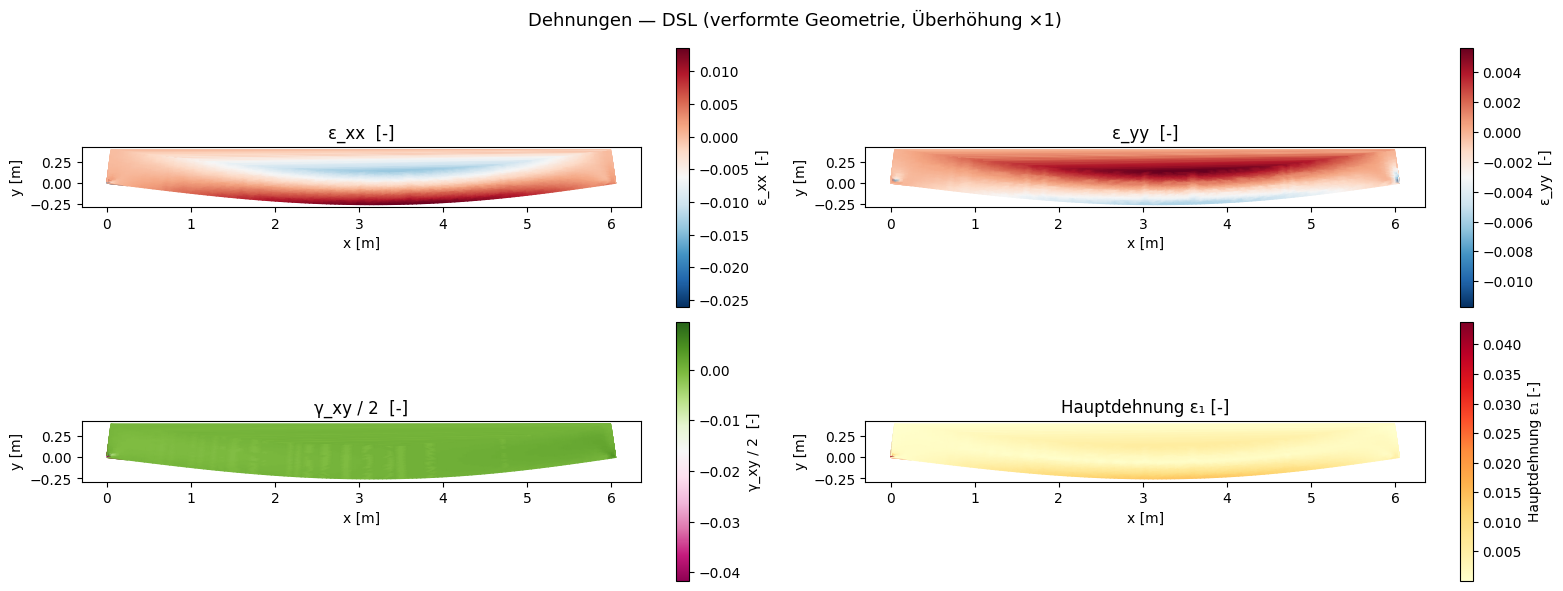

In [79]:
eps1 = 0.5*(exx + eyy) + onp.sqrt((0.5*(exx - eyy))**2 + exy**2)
eps2 = 0.5*(exx + eyy) - onp.sqrt((0.5*(exx - eyy))**2 + exy**2)

fig, axes = plt.subplots(2, 2, figsize=(16, 6))
axes = axes.flatten()

plots_eps = [
    (exx,  "ε_xx  [-]",         "RdBu_r"),
    (eyy,  "ε_yy  [-]",         "RdBu_r"),
    (exy,  "γ_xy / 2  [-]",     "PiYG"),
    (eps1, "Hauptdehnung ε₁ [-]", "YlOrRd"),
]

for ax, (data, label, cmap) in zip(axes, plots_eps):
    sc = ax.tripcolor(x_def, y_def, onp.array(data), shading="gouraud", cmap=cmap)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(label)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

plt.suptitle(f"Dehnungen — {SYSTEM} (verformte Geometrie, Überhöhung ×{scale:.0f})", fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Hauptspannungen & Trajektorien

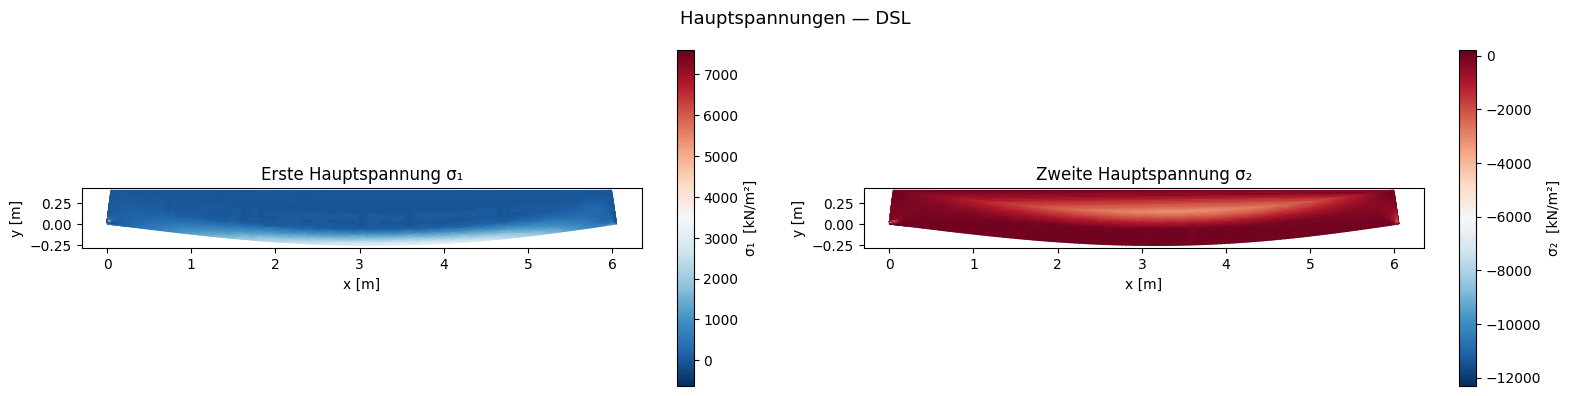

In [80]:
s1 = 0.5*(sxx + syy) + onp.sqrt((0.5*(sxx - syy))**2 + sxy**2)
s2 = 0.5*(sxx + syy) - onp.sqrt((0.5*(sxx - syy))**2 + sxy**2)
theta = 0.5 * onp.arctan2(2*sxy, sxx - syy)

e1x = onp.cos(theta)
e1y = onp.sin(theta)
e2x = -onp.sin(theta)
e2y =  onp.cos(theta)

# Hauptspannungsbeträge
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sc_s1 = axes[0].tripcolor(x_def, y_def, s1, shading="gouraud", cmap="RdBu_r")
plt.colorbar(sc_s1, ax=axes[0], label="σ₁  [kN/m²]")
axes[0].set_title("Erste Hauptspannung σ₁")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_aspect("equal")

sc_s2 = axes[1].tripcolor(x_def, y_def, s2, shading="gouraud", cmap="RdBu_r")
plt.colorbar(sc_s2, ax=axes[1], label="σ₂  [kN/m²]")
axes[1].set_title("Zweite Hauptspannung σ₂")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
axes[1].set_aspect("equal")

plt.suptitle(f"Hauptspannungen — {SYSTEM}", fontsize=13)
plt.tight_layout()
plt.show()

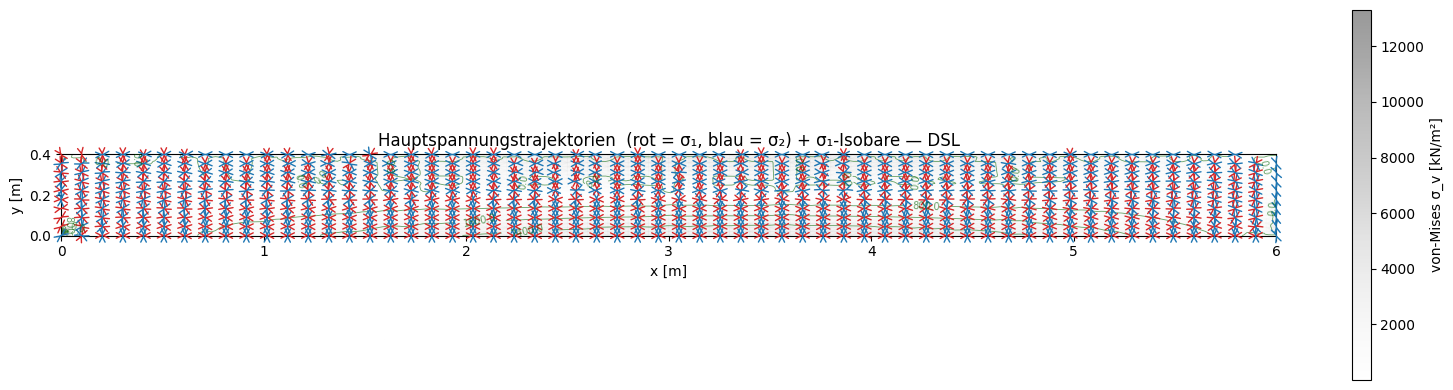

In [81]:
# Trajektorien-Plot (Vektorfeld + σ₁-Isobare)
interp_e1x = LinearNDInterpolator(points[:, :2], e1x)
interp_e1y = LinearNDInterpolator(points[:, :2], e1y)
interp_e2x = LinearNDInterpolator(points[:, :2], e2x)
interp_e2y = LinearNDInterpolator(points[:, :2], e2y)
interp_vm  = LinearNDInterpolator(points[:, :2], s_vm)
interp_s1  = LinearNDInterpolator(points[:, :2], s1)

nx_q = min(60, cfg["Nx"])
ny_q = min(10, cfg["Ny"])
xq = onp.linspace(0, Lx, nx_q)
yq = onp.linspace(0, h, ny_q)
Xq, Yq = onp.meshgrid(xq, yq)
pts_q = onp.column_stack([Xq.ravel(), Yq.ravel()])

E1x = interp_e1x(pts_q).reshape(ny_q, nx_q)
E1y = interp_e1y(pts_q).reshape(ny_q, nx_q)
E2x = interp_e2x(pts_q).reshape(ny_q, nx_q)
E2y = interp_e2y(pts_q).reshape(ny_q, nx_q)

fig, ax = plt.subplots(figsize=(16, 4))

sc = ax.tripcolor(points[:, 0], points[:, 1], s_vm, shading="gouraud",
                  cmap="Greys", alpha=0.4)
plt.colorbar(sc, ax=ax, label="von-Mises σ_v [kN/m²]")

hl = (h / ny_q) * 0.4
for i in range(ny_q):
    for j in range(nx_q):
        x0, y0 = Xq[i, j], Yq[i, j]
        dx1, dy1 = E1x[i, j], E1y[i, j]
        dx2, dy2 = E2x[i, j], E2y[i, j]
        if onp.isnan(dx1):
            continue
        ax.annotate("", xy=(x0+dx1*hl, y0+dy1*hl), xytext=(x0-dx1*hl, y0-dy1*hl),
                    arrowprops=dict(arrowstyle="<->", color="tab:red", lw=1.0))
        ax.annotate("", xy=(x0+dx2*hl, y0+dy2*hl), xytext=(x0-dx2*hl, y0-dy2*hl),
                    arrowprops=dict(arrowstyle="<->", color="tab:blue", lw=1.0))

# σ₁-Isobare
try:
    xi_c = onp.linspace(0, Lx, 300)
    yi_c = onp.linspace(0, h, 60)
    Xi_c, Yi_c = onp.meshgrid(xi_c, yi_c)
    S1_c = interp_s1(onp.column_stack([Xi_c.ravel(), Yi_c.ravel()])).reshape(60, 300)
    cs = ax.contour(Xi_c, Yi_c, S1_c, levels=10, colors="darkgreen", linewidths=0.6, alpha=0.6)
    ax.clabel(cs, fmt="%.1f", fontsize=7)
except Exception:
    pass

ax.set_xlim(0, Lx); ax.set_ylim(0, h)
ax.set_aspect("equal")
ax.set_title(f"Hauptspannungstrajektorien  (rot = σ₁, blau = σ₂) + σ₁-Isobare — {SYSTEM}")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.tight_layout()
plt.show()

### 5.6 Querschnittsplot: σ_xx über Trägerhöhe (Biegespannung)

### 5.7 Schnittgrößen: Biegemoment M, Querkraft V, Normalkraft N

Analytisch aus Auflagerreaktionen (Gleichgewicht am freigeschnittenen Teilstück) — klassische Balkenlösung als Referenz für die FEM-Spannungsfelder.

| Größe | Herleitung |
|-------|------------|
| **M(x)** | Moment aller Kräfte links des Schnitts |
| **V(x)** | Summe aller Querkräfte links des Schnitts |
| **N(x)** | Normalkraft (bei reiner Biegelast = 0) |

Vorzeichen: M > 0 = Zugfaser unten · V > 0 = Rechtsdrehung am linken Schnitt

RA=10.000 kN  RB=20.000 kN
M_max=23.094 kNm  bei x*=3.464 m = L/√3


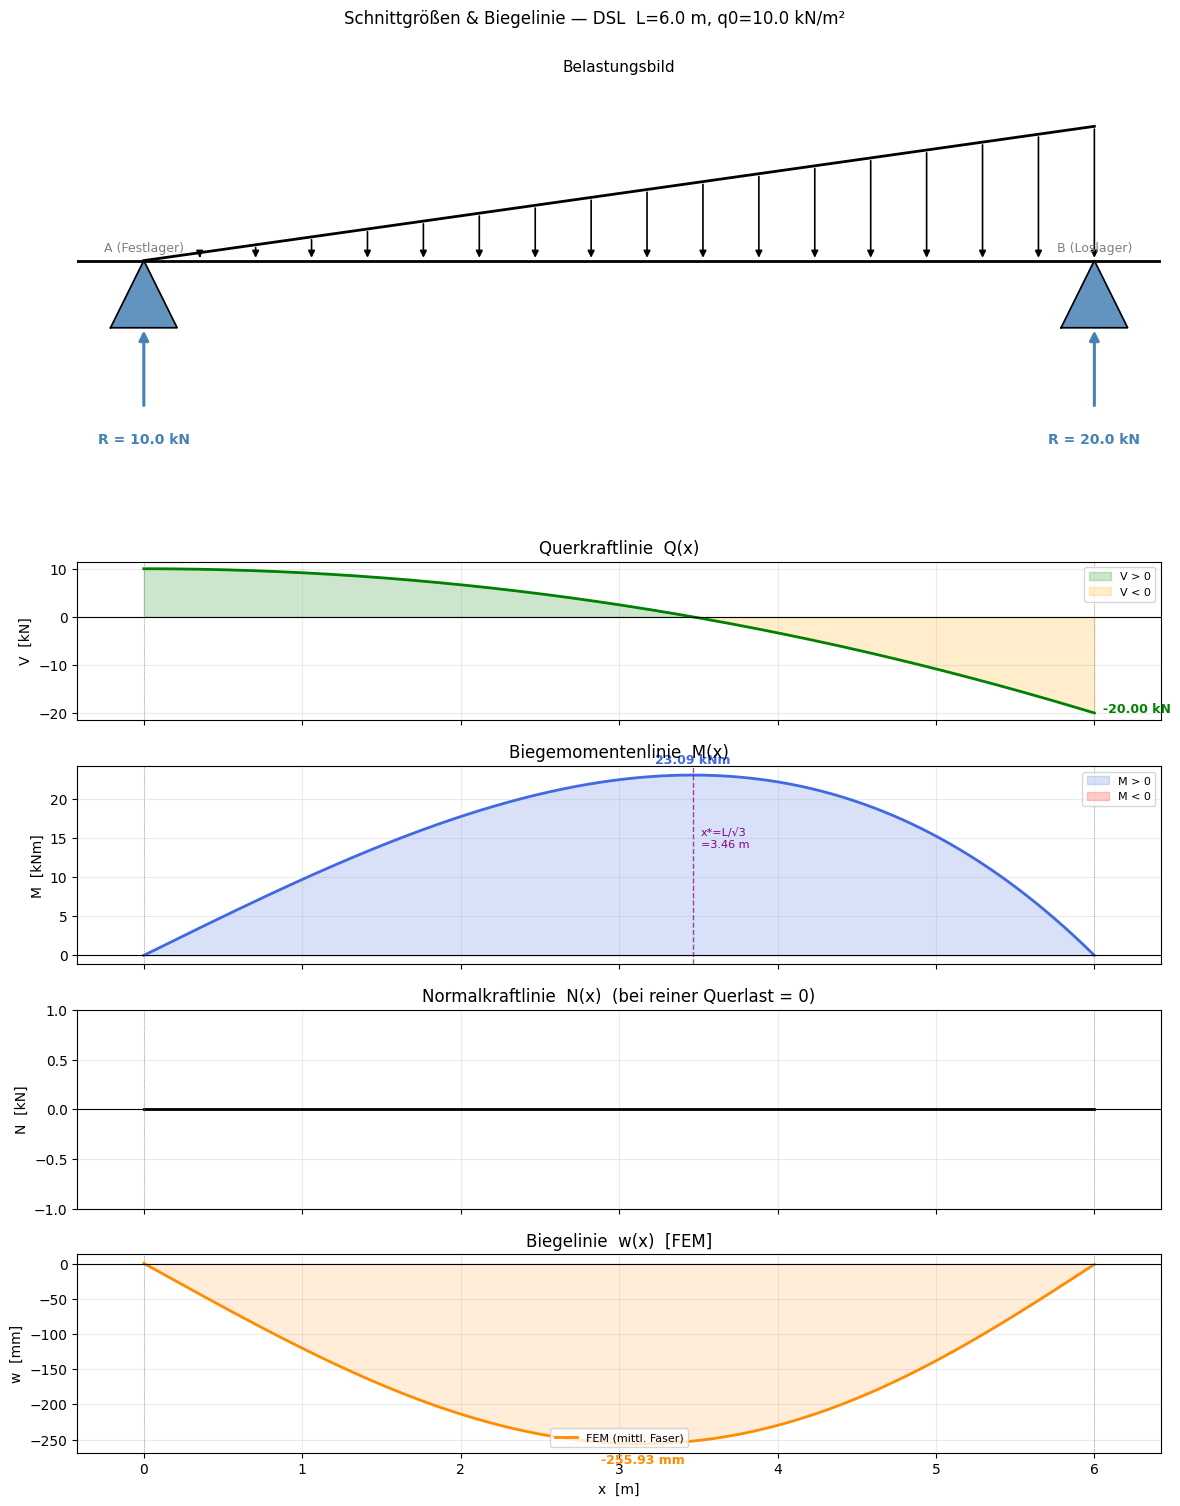

In [82]:
x_plot = onp.linspace(0, Lx, 1000)

# ── Auflagerreaktionen & Schnittgrößenfunktionen ──────────────────────────────
if SYSTEM == "EFK":
    L1, L2 = cfg["L1"], cfg["L2"]
    RA = (cfg["q"]*(L1+L2)**2/2 + F_krag*(L1+L2)) / L1
    RB = cfg["q"]*(L1+L2) + F_krag - RA
    q_func  = lambda x: onp.full_like(x, cfg["q"])
    def M_func(x):
        M1 = RA*x - cfg["q"]*x**2/2
        M2 = RA*x - cfg["q"]*x**2/2 - RB*(x-L1)
        return onp.where(x <= L1, M1, M2)
    def V_func(x):
        return onp.where(x <= L1, RA - cfg["q"]*x, RA - cfg["q"]*x + RB)
    def N_func(x): return onp.zeros_like(x)
    auflager_x = [0.0, L1];  auflager_R = [RA, RB]
    title_info = f"EFK  L1={L1} m, L2={L2} m, q={cfg['q']} kN/m²"
    print(f"RA={RA:.3f} kN  RB={RB:.3f} kN")

elif SYSTEM == "ZF":
    L1, L2 = cfg["L1"], cfg["L2"]; L = L1+L2
    MB = -cfg["q"]*(L1**3+L2**3)/(4*(L1+L2))
    RA = cfg["q"]*L1/2 - MB/L1
    RC = cfg["q"]*L2/2 - MB/L2
    RB = cfg["q"]*L - RA - RC
    q_func  = lambda x: onp.full_like(x, cfg["q"])
    def M_func(x):
        return onp.where(x <= L1,
            RA*x - cfg["q"]*x**2/2,
            RC*(L-x) - cfg["q"]*(L-x)**2/2)
    def V_func(x):
        return onp.where(x <= L1,
            RA - cfg["q"]*x,
            -(RC - cfg["q"]*(L-x)))
    def N_func(x): return onp.zeros_like(x)
    auflager_x = [0.0, L1, L];  auflager_R = [RA, RB, RC]
    title_info = f"ZF  L1={L1} m, L2={L2} m, q={cfg['q']} kN/m²"
    print(f"RA={RA:.3f} kN  RB={RB:.3f} kN  RC={RC:.3f} kN  MB={MB:.3f} kNm")

elif SYSTEM == "DSL":
    L = cfg["L"];  q0 = cfg["q0"]
    RA = q0*L/6;   RB = q0*L/3
    q_func  = lambda x: q0 * x / L
    def M_func(x): return RA*x - q0*x**3/(6*L)
    def V_func(x): return RA - q0*x**2/(2*L)
    def N_func(x): return onp.zeros_like(x)
    x_star    = L / onp.sqrt(3)
    M_max_ana = q0*L**2 / (9*onp.sqrt(3))
    auflager_x = [0.0, L];  auflager_R = [RA, RB]
    title_info = f"DSL  L={L} m, q0={q0} kN/m²"
    print(f"RA={RA:.3f} kN  RB={RB:.3f} kN")
    print(f"M_max={M_max_ana:.3f} kNm  bei x*={x_star:.3f} m = L/\u221a3")

M_vals = M_func(x_plot)
V_vals = V_func(x_plot)
N_vals = N_func(x_plot)
q_vals = q_func(x_plot)

# Biegelinie aus FEM: mittlere Faser (y \u2248 h/2)
tol_mid = (h / cfg["Ny"]) * 0.8
mask_mid = onp.abs(points[:, 1] - h/2) < tol_mid
x_bl = points[mask_mid, 0]
w_bl = onp.array(uy)[mask_mid]
sort_bl = onp.argsort(x_bl)
x_bl = x_bl[sort_bl];  w_bl = w_bl[sort_bl]

# ── 5 Subplots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 0.8, 1, 1, 1]})
fig.suptitle(f"Schnittgrößen & Biegelinie — {title_info}", fontsize=12, y=1.001)

# ① Systemskizze: Belastung + Auflager
ax = axes[0]
q_max = q_vals.max()
arrow_h = q_max * 0.7

# Auflager-Geometrie skaliert zur Spannweite
tri_w = Lx * 0.035        # Dreiecksbreite  ≈ 3.5 % der Spannweite
tri_h = arrow_h * 0.50    # Dreieckshöhe    ≈ 50 % der Pfeilhöhe
gap   = arrow_h * 0.08    # Abstand Dreieck–Text

ax.set_xlim(-tri_w * 2, Lx + tri_w * 2)

# Lastpfeile
n_arrows = 18
for xi in onp.linspace(0, Lx, n_arrows):
    qi = float(q_func(onp.array([xi]))[0])
    if qi > 1e-6:
        ax.annotate("", xy=(xi, 0), xytext=(xi, qi/q_max * arrow_h),
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2,
                                    mutation_scale=10))
# Lastlinie oben
ax.plot(x_plot, q_vals/q_max * arrow_h, "k-", lw=2.0)
ax.axhline(0, color="black", lw=2.0)  # Trägerlinie

# Auflager-Dreiecke (skaliert)
for xr, Rr in zip(auflager_x, auflager_R):
    tri_x = [xr - tri_w, xr + tri_w, xr, xr - tri_w]
    tri_y = [-tri_h,     -tri_h,     0,  -tri_h     ]
    ax.fill(tri_x, tri_y, color="steelblue", zorder=5, alpha=0.85)
    ax.plot(tri_x, tri_y, "k-", lw=1.2, zorder=6)
    # Reaktionskraft-Pfeil nach oben unterhalb des Dreiecks
    ax.annotate("", xy=(xr, -tri_h), xytext=(xr, -tri_h * 2.2),
                arrowprops=dict(arrowstyle="-|>", color="steelblue", lw=2.2,
                                mutation_scale=14))
    ax.text(xr, -tri_h * 2.4 - gap,
            f"R = {Rr:.1f} kN", ha="center", va="top",
            fontsize=10, color="steelblue", fontweight="bold")

# Auflager-Labels A/B/C
lbl_map = {auflager_x[0]: "A (Festlager)", auflager_x[-1]: "B (Loslager)"}
if SYSTEM == "ZF":
    lbl_map = {0.0: "A", cfg["L1"]: "B", Lx: "C"}
for xr, lbl in lbl_map.items():
    ax.text(xr, gap * 0.6, lbl, ha="center", va="bottom", fontsize=9, color="gray")

ax.set_ylim(-tri_h * 3.8, arrow_h * 1.35)
ax.set_title("Belastungsbild", fontsize=11)
ax.set_ylabel("Last  [—]")
ax.axis("off")

# ② Querkraftlinie
ax = axes[1]
ax.plot(x_plot, V_vals, color="green", lw=2)
ax.fill_between(x_plot, 0, V_vals, where=(V_vals>=0), alpha=0.2, color="green", label="V > 0")
ax.fill_between(x_plot, 0, V_vals, where=(V_vals< 0), alpha=0.2, color="orange", label="V < 0")
ax.axhline(0, color="black", lw=0.8)
for xr in auflager_x: ax.axvline(xr, color="gray", lw=0.5, ls=":")
i_v = onp.argmax(onp.abs(V_vals))
ax.annotate(f"{V_vals[i_v]:.2f} kN", xy=(x_plot[i_v], V_vals[i_v]),
            xytext=(6, 0), textcoords="offset points", fontsize=9,
            color="green", fontweight="bold")
ax.set_ylabel("V  [kN]"); ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=0.25)
ax.set_title("Querkraftlinie  Q(x)")

# ③ Biegemomentenlinie
ax = axes[2]
ax.plot(x_plot, M_vals, color="royalblue", lw=2)
ax.fill_between(x_plot, 0, M_vals, where=(M_vals>=0), alpha=0.2, color="royalblue", label="M > 0")
ax.fill_between(x_plot, 0, M_vals, where=(M_vals< 0), alpha=0.2, color="red",       label="M < 0")
ax.axhline(0, color="black", lw=0.8)
for xr in auflager_x: ax.axvline(xr, color="gray", lw=0.5, ls=":")
i_max = onp.argmax(M_vals); i_min = onp.argmin(M_vals)
ax.annotate(f"{M_vals[i_max]:.2f} kNm", xy=(x_plot[i_max], M_vals[i_max]),
            xytext=(0, 8), textcoords="offset points", ha="center",
            fontsize=9, color="royalblue", fontweight="bold")
if abs(M_vals[i_min]) > 1e-3:
    ax.annotate(f"{M_vals[i_min]:.2f} kNm", xy=(x_plot[i_min], M_vals[i_min]),
                xytext=(0,-13), textcoords="offset points", ha="center",
                fontsize=9, color="red", fontweight="bold")
if SYSTEM == "DSL":
    ax.axvline(x_star, color="purple", lw=1, ls="--", alpha=0.7)
    ax.text(x_star + 0.05, M_vals.max()*0.6,
            f"x*=L/\u221a3\n={x_star:.2f} m", fontsize=8, color="purple")
ax.set_ylabel("M  [kNm]"); ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=0.25)
ax.set_title("Biegemomentenlinie  M(x)")

# ④ Normalkraftlinie
ax = axes[3]
ax.plot(x_plot, N_vals, "k-", lw=2)
ax.fill_between(x_plot, 0, N_vals, alpha=0.12, color="black")
ax.axhline(0, color="black", lw=0.8)
for xr in auflager_x: ax.axvline(xr, color="gray", lw=0.5, ls=":")
ax.set_ylabel("N  [kN]"); ax.grid(True, alpha=0.25)
ax.set_title("Normalkraftlinie  N(x)  (bei reiner Querlast = 0)")
ax.set_ylim(-1, 1)

# ⑤ Biegelinie (FEM)
ax = axes[4]
ax.plot(x_bl, w_bl * 1000, color="darkorange", lw=2, label="FEM (mittl. Faser)")
ax.axhline(0, color="black", lw=0.8)
for xr in auflager_x: ax.axvline(xr, color="gray", lw=0.5, ls=":")
i_w = onp.argmin(w_bl)
ax.annotate(f"{w_bl[i_w]*1000:.2f} mm", xy=(x_bl[i_w], w_bl[i_w]*1000),
            xytext=(0, -14), textcoords="offset points", ha="center",
            fontsize=9, color="darkorange", fontweight="bold")
ax.fill_between(x_bl, 0, w_bl*1000, alpha=0.15, color="darkorange")
ax.set_ylabel("w  [mm]"); ax.set_xlabel("x  [m]")
ax.legend(fontsize=8, loc="lower center"); ax.grid(True, alpha=0.25)
ax.set_title("Biegelinie  w(x)  [FEM]")

plt.tight_layout()
plt.show()


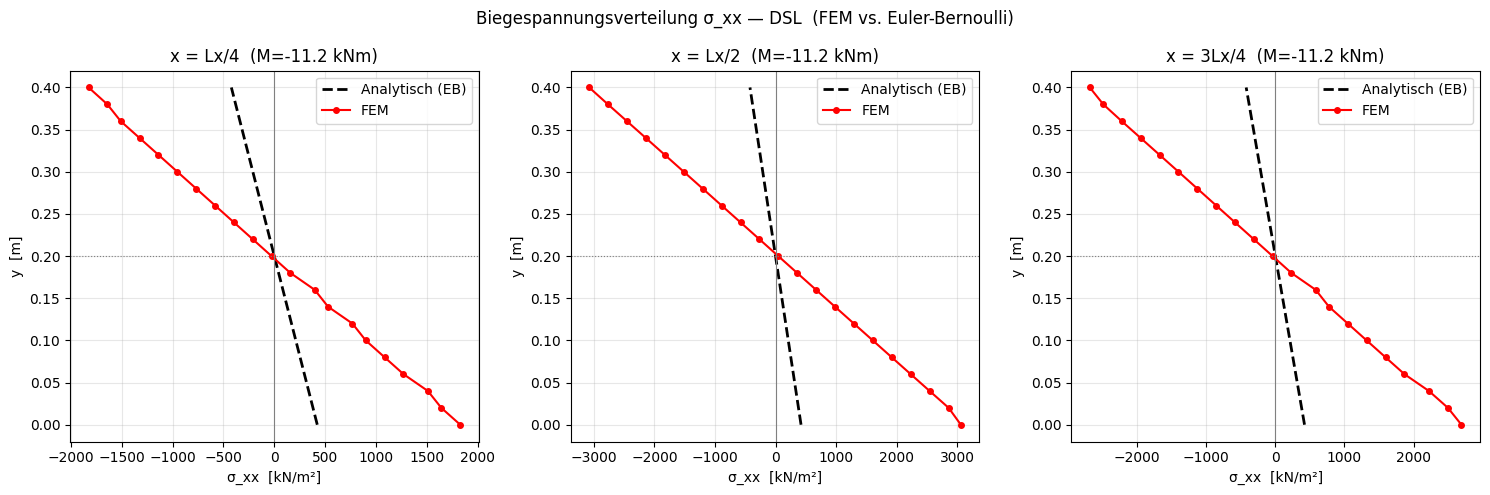

In [83]:
I = 1.0 * h**3 / 12.0
y_center = h / 2.0
tol_x_plot = (Lx / cfg["Nx"]) * 0.6

# Schnitte: linkes Viertel, Mitte, rechtes Viertel
x_cuts = {
    "x = Lx/4": Lx / 4,
    "x = Lx/2": Lx / 2,
    "x = 3Lx/4": 3 * Lx / 4,
}

fig, axes = plt.subplots(1, len(x_cuts), figsize=(5 * len(x_cuts), 5))
if len(x_cuts) == 1:
    axes = [axes]

for ax, (label, x_cut) in zip(axes, x_cuts.items()):
    mask = onp.abs(points[:, 0] - x_cut) < tol_x_plot
    y_fem_s = points[mask, 1]
    sxx_s   = sxx[mask]
    sort_i  = onp.argsort(y_fem_s)

    # Analytisches Biegemoment
    if SYSTEM == "EFK":
        L1 = cfg["L1"]
        L2 = cfg["L2"]
        # Auflagerreaktion A (Gelenk A–B, Streckenlast + Kragarm)
        # RA = (q*L1*L1/2 + q*L2*(L1+L2/2) + F_krag*(L1+L2)) / L1
        RA = (q*L1*L1/2 + q*L2*(L1+L2/2) + F_krag*(L1+L2)) / L1
        if x_cut <= L1:
            M_ana = RA * x_cut - q * x_cut**2 / 2
        else:
            dx = x_cut - L1
            M_ana = -q * (L1 + L2 - x_cut)**2 / 2 - F_krag * (L1 + L2 - x_cut)
    elif SYSTEM == "ZF":
        L1 = cfg["L1"]; L2 = cfg["L2"]; L = L1 + L2
        # Dreimomentensatz: MA=MC=0, MB aus Kompatibilität
        # Für gleiche q: MB = -q*L1^2*L2^2 / (8*(L1+L2)) vereinfacht
        # Allgemein: q*(L1^3/L1 + L2^3/L2) * 1/(4*(L1+L2))
        MB = -q * (L1**3 + L2**3) / (4 * (L1 + L2))
        if x_cut <= L1:
            RA = (q*L1/2 + MB/L1)
            M_ana = RA * x_cut - q * x_cut**2 / 2
        else:
            dx = x_cut - L1
            RC = (q*L2/2 + MB/L2)
            M_ana = RC * (L - x_cut) - q * (L - x_cut)**2 / 2

    y_vals_ana = onp.linspace(0, h, 200)
    sigma_ana  = M_ana * (y_vals_ana - y_center) / I

    ax.plot(sigma_ana, y_vals_ana, "k--", lw=2, label="Analytisch (EB)")
    ax.plot(sxx_s[sort_i], y_fem_s[sort_i], "ro-", ms=4, label="FEM")
    ax.axvline(0, color="gray", lw=0.8)
    ax.axhline(y_center, color="gray", lw=0.8, linestyle=":")
    ax.set_xlabel("σ_xx  [kN/m²]")
    ax.set_ylabel("y  [m]")
    ax.set_title(f"{label}  (M={M_ana:.1f} kNm)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Biegespannungsverteilung σ_xx — {SYSTEM}  (FEM vs. Euler-Bernoulli)", fontsize=12)
plt.tight_layout()
plt.show()